# A股银行板块动量因子分析

- 数据来源：Tushare Pro
- 分析区间：2019-2024年
- 股票池：A股30只银行股
- 核心结论：银行板块动量因子IC均值=-0.029，存在显著反转效应，分组收益单调递减

In [1]:
import tinyshare as ts
import pandas as pd
import time

ts.set_token('VXFid62Cnt0a2PBf3jAOi0v7nBjDPek696iEdh0oOLDboBDjwBOowTzR1701da1f')
pro = ts.pro_api()

# 直接用申万银行行业分类获取成分股
stocks = pro.index_member_all(index_code='801780.SI')
print(stocks.head())
print(f'共{len(stocks)}只股票')

     l1_code l1_name    l2_code l2_name    l3_code l3_name    ts_code  name  \
0  801880.SI      汽车  801881.SI  摩托车及其他  858811.SI  其他运输设备  600679.SH  上海凤凰   
1  801180.SI     房地产  801181.SI   房地产开发  851811.SI    住宅开发  600683.SH  京投发展   
2  801740.SI    国防军工  801744.SI   航海装备Ⅱ  850935.SI   航海装备Ⅲ  600685.SH  中船防务   
3  801880.SI      汽车  801096.SI     商用车  850913.SI   商用载客车  600686.SH  金龙汽车   
4  801960.SI    石油石化  801963.SI   炼化及贸易  859631.SI    炼油化工  600688.SH  上海石化   

    in_date out_date is_new  
0  19931008     None      Y  
1  19931025     None      Y  
2  19931028     None      Y  
3  19931108     None      Y  
4  19931108     None      Y  
共3000只股票


In [2]:
# 筛选出银行板块（l2_code = 801780.SI）
bank_stocks = stocks[stocks['l2_code'] == '801780.SI']
stock_list = bank_stocks['ts_code'].tolist()
print(f'银行板块共{len(stock_list)}只股票')
print(stock_list)

银行板块共0只股票
[]


In [3]:
# 直接指定A股全部上市银行股票代码
stock_list = [
    '601398.SH', '601288.SH', '601939.SH', '601658.SH', '600036.SH',
    '601166.SH', '600016.SH', '601328.SH', '601988.SH', '601818.SH',
    '000001.SZ', '002142.SZ', '600000.SH', '601009.SH', '601169.SH',
    '601229.SH', '601577.SH', '002958.SZ', '601128.SH', '601187.SH',
    '600926.SH', '002966.SZ', '603323.SH', '601963.SH', '002936.SZ',
    '001227.SZ', '600908.SH', '601916.SH', '601860.SH', '002807.SZ'
]

print(f'共{len(stock_list)}只银行股')

# 循环拉取前5只测试
all_data = {}
for code in stock_list[:5]:
    try:
        df = pro.daily(
            ts_code=code,
            start_date='20190101',
            end_date='20241231'
        )
        all_data[code] = df
        print(f'{code} 获取成功，{len(df)}条记录')
        time.sleep(0.3)
    except Exception as e:
        print(f'{code} 失败: {e}')

print('完成，共获取', len(all_data), '只股票')

共30只银行股
601398.SH 获取成功，1456条记录
601288.SH 获取成功，1456条记录
601939.SH 获取成功，1456条记录
601658.SH 获取成功，1228条记录
600036.SH 获取成功，1456条记录
完成，共获取 5 只股票


In [4]:
# 拉取全部30只银行股
all_data = {}
for i, code in enumerate(stock_list):
    try:
        df = pro.daily(
            ts_code=code,
            start_date='20190101',
            end_date='20241231'
        )
        all_data[code] = df
        print(f'[{i+1}/30] {code} 成功，{len(df)}条')
        time.sleep(0.4)  # 免费账号限速，稍微慢一点
    except Exception as e:
        print(f'[{i+1}/30] {code} 失败: {e}')

print(f'\n全部完成，成功获取 {len(all_data)} 只股票')

# 合并成收盘价矩阵并保存
close_dict = {}
for code, df in all_data.items():
    df = df.sort_values('trade_date')
    close_dict[code] = df.set_index('trade_date')['close']

close_df = pd.DataFrame(close_dict)
close_df.index = pd.to_datetime(close_df.index)
close_df.to_csv(r'D:\quant_pro\project1_quant\data\close_prices.csv')
print('已保存，shape:', close_df.shape)

[1/30] 601398.SH 成功，1456条
[2/30] 601288.SH 成功，1456条
[3/30] 601939.SH 成功，1456条
[4/30] 601658.SH 成功，1228条
[5/30] 600036.SH 成功，1456条
[6/30] 601166.SH 成功，1456条
[7/30] 600016.SH 成功，1456条
[8/30] 601328.SH 成功，1456条
[9/30] 601988.SH 成功，1456条
[10/30] 601818.SH 成功，1456条
[11/30] 000001.SZ 成功，1456条
[12/30] 002142.SZ 成功，1450条
[13/30] 600000.SH 成功，1456条
[14/30] 601009.SH 成功，1456条
[15/30] 601169.SH 成功，1456条
[16/30] 601229.SH 成功，1456条
[17/30] 601577.SH 成功，1456条
[18/30] 002958.SZ 成功，1402条
[19/30] 601128.SH 成功，1456条
[20/30] 601187.SH 成功，1017条
[21/30] 600926.SH 成功，1456条
[22/30] 002966.SZ 成功，1314条
[23/30] 603323.SH 成功，1456条
[24/30] 601963.SH 成功，945条
[25/30] 002936.SZ 成功，1456条
[26/30] 001227.SZ 成功，717条
[27/30] 600908.SH 成功，1456条
[28/30] 601916.SH 成功，1232条
[29/30] 601860.SH 成功，1455条
[30/30] 002807.SZ 成功，1456条

全部完成，成功获取 30 只股票
已保存，shape: (1456, 30)


In [5]:
import pandas as pd
import numpy as np

close_df = pd.read_csv(r'D:\quant_pro\project1_quant\data\close_prices.csv', 
                       index_col=0, parse_dates=True)

# 删除上市不足1年的股票
close_df = close_df.dropna(thresh=int(len(close_df) * 0.8), axis=1)

# 前向填充停牌日
close_df = close_df.fillna(method='ffill')

# 计算日收益率
returns = close_df.pct_change().dropna()

# 计算下期20日收益率（用于计算IC）
forward_20d = close_df.pct_change(20).shift(-20)

print('股票数量:', close_df.shape[1])
print('交易日数量:', close_df.shape[0])
print('收益率矩阵 shape:', returns.shape)

股票数量: 27
交易日数量: 1456
收益率矩阵 shape: (1227, 27)


C:\Users\wzy\AppData\Local\Temp\ipykernel_19636\2798973161.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_df = close_df.fillna(method='ffill')


In [6]:
# 因子：动量因子（过去20日累计收益率）
factor = close_df.pct_change(20)

print('因子矩阵 shape:', factor.shape)
print(factor.tail(3))

因子矩阵 shape: (1456, 27)
            601398.SH  601288.SH  601939.SH  601658.SH  600036.SH  601166.SH  \
trade_date                                                                     
2024-12-27   0.125203   0.103950   0.098997   0.054717   0.082554   0.072022   
2024-12-30   0.133768   0.114108   0.108312   0.061453   0.085182   0.074766   
2024-12-31   0.114332   0.092025   0.089219   0.036496   0.058728   0.038482   

            600016.SH  601328.SH  601988.SH  601818.SH  ...  002958.SZ  \
trade_date                                              ...              
2024-12-27   0.035354   0.051842   0.093812   0.061111  ...  -0.003215   
2024-12-30   0.052764   0.080110   0.103792   0.086111  ...   0.003215   
2024-12-31   0.022277   0.057143   0.082515   0.048780  ...  -0.041009   

            601128.SH  600926.SH  002966.SZ  603323.SH  002936.SZ  600908.SH  \
trade_date                                                                     
2024-12-27  -0.021025   0.035336   0.022727  

In [7]:
from scipy import stats

ic_series = []
for date in factor.index[:-20]:
    f = factor.loc[date].dropna()
    r = forward_20d.loc[date].dropna()
    common = f.index.intersection(r.index)
    if len(common) < 5:
        continue
    ic, _ = stats.spearmanr(f[common], r[common])
    ic_series.append({'date': date, 'IC': ic})

ic_df = pd.DataFrame(ic_series).set_index('date')
ic_mean = ic_df['IC'].mean()
ic_std  = ic_df['IC'].std()
icir    = ic_mean / ic_std

print(f'IC均值:  {ic_mean:.4f}')
print(f'IC标准差: {ic_std:.4f}')
print(f'ICIR:    {icir:.4f}')
print(f'计算了{len(ic_df)}个交易日的IC')

IC均值:  -0.0293
IC标准差: 0.3151
ICIR:    -0.0929
计算了1416个交易日的IC


In [8]:
group_returns = {i: [] for i in range(1, 6)}

for date in factor.index[:-20]:
    f = factor.loc[date].dropna()
    r = forward_20d.loc[date].dropna()
    common = f.index.intersection(r.index)
    if len(common) < 10:
        continue
    f_sorted = f[common].rank(pct=True)
    for g in range(1, 6):
        low  = (g - 1) / 5
        high = g / 5
        mask = (f_sorted > low) & (f_sorted <= high)
        avg_r = r[common][mask].mean()
        group_returns[g].append(avg_r)

for g in range(1, 6):
    avg = pd.Series(group_returns[g]).mean()
    print(f'第{g}组平均收益: {avg * 100:.3f}%')

第1组平均收益: 0.478%
第2组平均收益: 0.089%
第3组平均收益: 0.026%
第4组平均收益: 0.011%
第5组平均收益: -0.105%


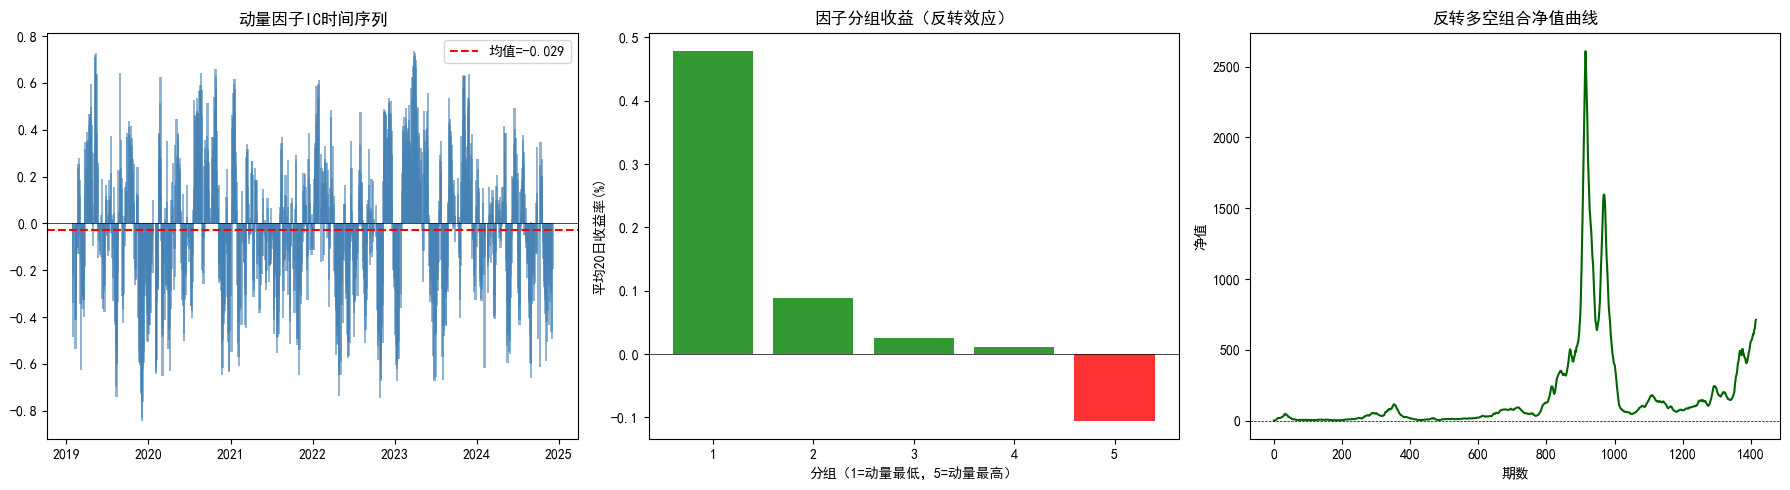

图表已保存


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：IC时间序列
axes[0].bar(ic_df.index, ic_df['IC'], color='steelblue', alpha=0.6, width=10)
axes[0].axhline(y=ic_mean, color='red', linestyle='--', label=f'均值={ic_mean:.3f}')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('动量因子IC时间序列')
axes[0].legend()

# 图2：分组平均收益柱状图
group_avg = [pd.Series(group_returns[g]).mean() * 100 for g in range(1, 6)]
colors = ['green' if x > 0 else 'red' for x in group_avg]
axes[1].bar(range(1, 6), group_avg, color=colors, alpha=0.8)
axes[1].set_xlabel('分组（1=动量最低，5=动量最高）')
axes[1].set_ylabel('平均20日收益率(%)')
axes[1].set_title('因子分组收益（反转效应）')
axes[1].axhline(y=0, color='black', linewidth=0.5)

# 图3：多空组合净值曲线（注意：这里做反转，买第1组卖第5组）
long_ret  = pd.Series(group_returns[1])  # 买入动量最低组
short_ret = pd.Series(group_returns[5])  # 卖出动量最高组
ls_ret    = long_ret - short_ret
nav       = (1 + ls_ret).cumprod()
axes[2].plot(nav.values, color='darkgreen', linewidth=1.5)
axes[2].axhline(y=1, color='black', linewidth=0.5, linestyle='--')
axes[2].set_title('反转多空组合净值曲线')
axes[2].set_xlabel('期数')
axes[2].set_ylabel('净值')

plt.tight_layout()
plt.savefig(r'D:\quant_pro\project1_quant\output\factor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存')